In [1]:
import pandas as pd

df = pd.read_csv("Stock_data.csv")

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.set_index('Date', inplace=True)

print(df.head())

             Open    High     Low    Last   Close  Total Trade Quantity  \
Date                                                                      
2010-07-21  122.1  123.00  121.05  121.10  121.55                658666   
2010-07-22  120.3  122.00  120.25  120.75  120.90                293312   
2010-07-23  121.8  121.95  120.25  120.35  120.65                281312   
2010-07-26  120.1  121.00  117.10  117.10  117.60                658440   
2010-07-27  117.6  119.50  112.00  118.80  118.65                586100   

            Turnover (Lacs)  
Date                         
2010-07-21           803.56  
2010-07-22           355.17  
2010-07-23           340.31  
2010-07-26           780.01  
2010-07-27           694.98  


In [3]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 4.2 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 5.8 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 6.1 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 6.6 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 6.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.9 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ----


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.901358473953878
p-value: 0.7875247234994132


In [5]:
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()

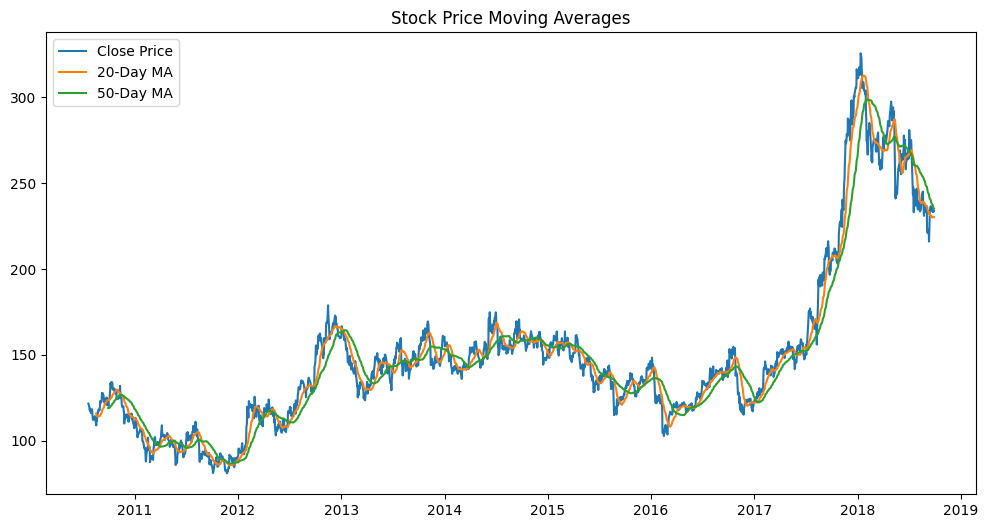

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA20'], label='20-Day MA')
plt.plot(df['MA50'], label='50-Day MA')

plt.legend()
plt.title("Stock Price Moving Averages")
plt.show()

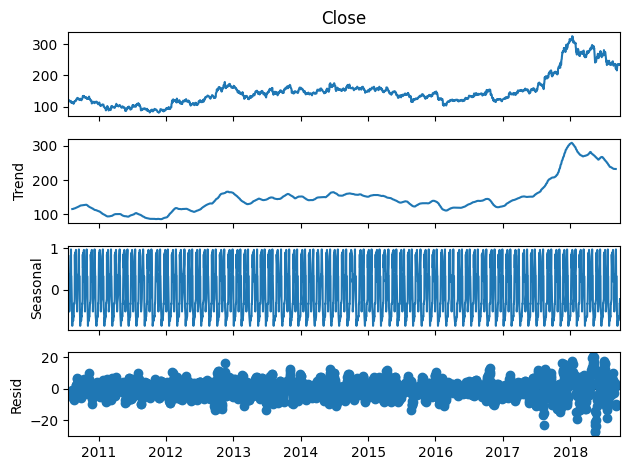

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df['Close'],
    model='additive',
    period=30
)

result.plot()
plt.show()

In [8]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Close'], order=(5,1,0))

model_fit = model.fit()

forecast = model_fit.forecast(30)

print(forecast)

C:\Users\adars\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\adars\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\adars\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


2035    233.670977
2036    233.634190
2037    233.697830
2038    233.706919
2039    233.698247
2040    233.701983
2041    233.701658
2042    233.700099
2043    233.700146
2044    233.700228
2045    233.700126
2046    233.700163
2047    233.700193
2048    233.700189
2049    233.700190
2050    233.700192
2051    233.700191
2052    233.700191
2053    233.700191
2054    233.700191
2055    233.700191
2056    233.700191
2057    233.700191
2058    233.700191
2059    233.700191
2060    233.700191
2061    233.700191
2062    233.700191
2063    233.700191
2064    233.700191
Name: predicted_mean, dtype: float64


C:\Users\adars\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\adars\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


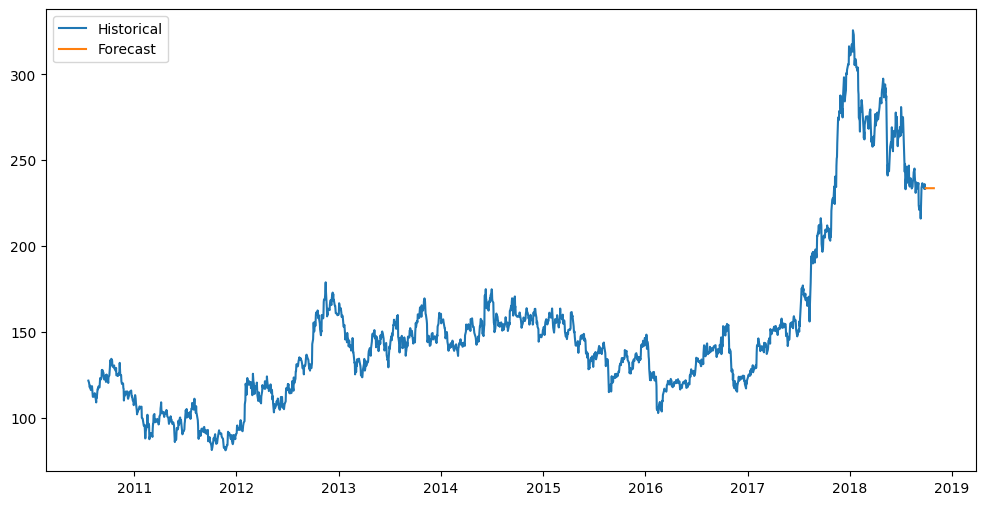

In [9]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='Historical')

future_dates = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq='D'
)[1:]

plt.plot(
    future_dates,
    forecast,
    label='Forecast'
)

plt.legend()
plt.show()